# Reinforcement Learning Model Analysis 

In [ ]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict, List, Callable

from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

#change this to respective path
FEUDAL_FILE = '/Users/jojona/Documents/Learning/Masters/COMPSCI 760/COMPSCI_760_Reinforcement/Atari/model_data/feudal_MsPacman-v5'
QLEARN_FILE = '/Users/jojona/Documents/Learning/Masters/COMPSCI 760/COMPSCI_760_Reinforcement/Atari/model_data/qlearn_MsPacman-v5'

ALGORITHMS = {
    'Feudal': FEUDAL_FILE,
    'Q-learning': QLEARN_FILE
}

# Plotting colors for consistency
COLORS = {
    'Feudal': '#377eb8',
    'Q-learning': "#058f2a",
    'Feudal_Profile': '#7645df',
    'Q_Profile': '#37b85c'
}
RANDOM_SCORE = 307.3
HUMAN_SCORE = 6957.0


In [ ]:
# Help funcs

def load_scores(file_path: str) -> np.ndarray:
    """Loads scores from a JSON file and returns them as a NumPy array."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        

        scores_series = pd.Series(data.values())
        return pd.to_numeric(scores_series, errors='coerce').dropna().values

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return np.array([])

def plot_score_distribution(scores: np.ndarray, algo_name: str):
    """Plots the score distribution histogram with mean, median, and IQM."""
    if scores.size == 0:
        print(f"No scores to plot for {algo_name}.")
        return

    mean_score = np.mean(scores)
    median_score = np.median(scores)
    q1, q3 = np.percentile(scores, [25, 75])
    iqm_scores = scores[(scores >= q1) & (scores <= q3)]
    iqm_score = np.mean(iqm_scores) if iqm_scores.size > 0 else median_score

    plt.figure(figsize=(10, 6))
    sns.histplot(scores, bins=20, kde=True, color='skyblue')
    plt.axvline(mean_score, color='red', linestyle='--', lw=2, label=f'Mean: {mean_score:.2f}')
    plt.axvline(median_score, color='green', linestyle='--', lw=2, label=f'Median: {median_score:.2f}')
    plt.axvline(iqm_score, color='purple', linestyle='--', lw=2, label=f'IQM: {iqm_score:.2f}')
    plt.title(f'Score Distribution of {algo_name} on Ms. Pac-Man', fontsize=16)
    plt.xlabel('Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.show()

def plot_annotated_profile(scores: np.ndarray, profile: np.ndarray, thresholds: np.ndarray, algo_name: str, color: str):
    """Plots a detailed performance profile with IQM and Optimality Gap shaded."""
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.plot(thresholds, profile, color=color, linewidth=2.5)

    human_level_mask = thresholds <= 1.0
    ax.fill_between(thresholds[human_level_mask], profile[human_level_mask], 1,
                    color='orange', alpha=0.7, label='Optimality Gap')

    x_25, x_75 = np.percentile(scores, [25, 75])
    iqm_mask = (thresholds >= x_25) & (thresholds <= x_75)
    ax.fill_between(thresholds[iqm_mask], profile[iqm_mask], 0,
                    color='red', alpha=0.7, label='IQM')

    y_25 = profile[np.argmin(np.abs(thresholds - x_75))]
    y_75 = profile[np.argmin(np.abs(thresholds - x_25))]
    ax.axhline(y=y_25, xmax=(x_75 / ax.get_xlim()[1]), ls=":", color='black', alpha=0.8)
    ax.axhline(y=y_75, xmax=(x_25 / ax.get_xlim()[1]), ls=":", color='black', alpha=0.8)
    ax.axvline(x=x_25, ymax=(y_75 / ax.get_ylim()[1]), ls=":", color='black', alpha=0.8)
    ax.axvline(x=x_75, ymax=(y_25 / ax.get_ylim()[1]), ls=":", color='black', alpha=0.8)

    ax.set_ylabel(r'P( Score > $\tau)$', fontsize='x-large')
    ax.set_xlabel('Normalized Score ' + r'$(\tau)$', fontsize='x-large')
    ax.set_title(f'Performance Profile Metrics for {algo_name}', fontsize=16, pad=15)
    ax.tick_params(labelsize='large')
    ax.set_xlim(left=0.0)
    ax.set_ylim(bottom=0.0, top=1.05)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize='large', loc='upper right')
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.show()


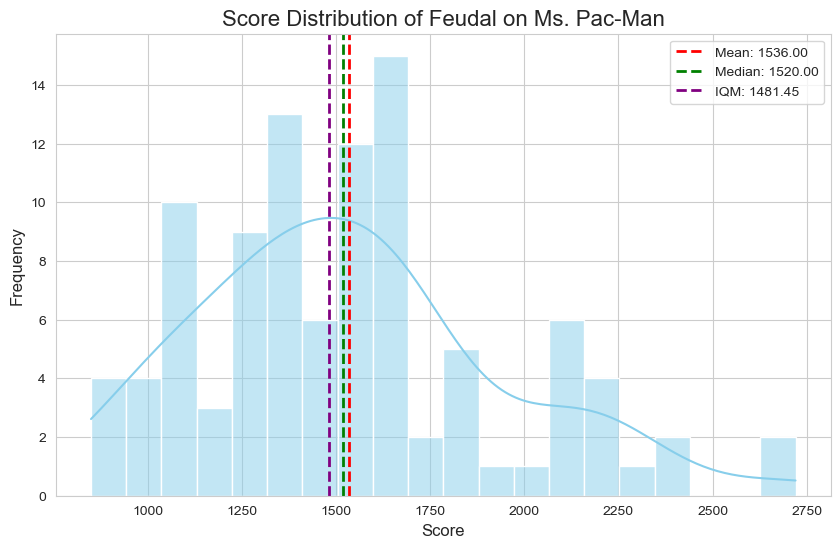

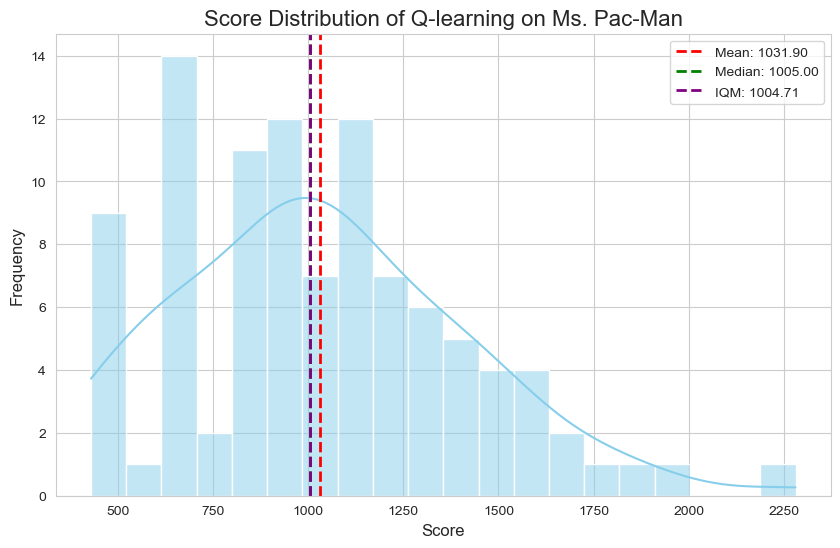

In [ ]:
# Data load
sns.set_style("whitegrid")
raw_scores = {name: load_scores(path) for name, path in ALGORITHMS.items()}

for name, scores in raw_scores.items():
    plot_score_distribution(scores, name)

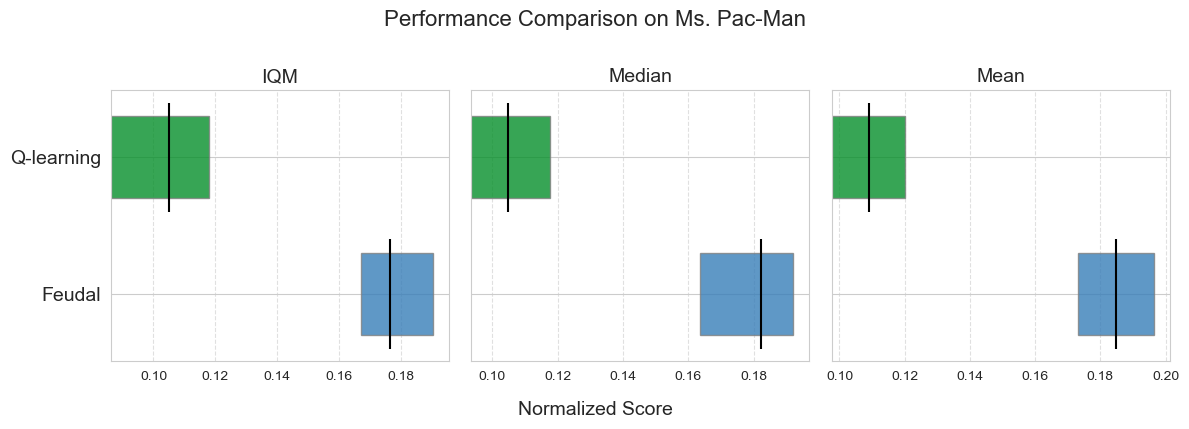

In [ ]:
# Perf Comparison with CI's

normalized_scores = {
    algo: (scores.astype(float) - RANDOM_SCORE) / (HUMAN_SCORE - RANDOM_SCORE)
    for algo, scores in raw_scores.items()
}

def calculate_iqm(data):
    q1, q3 = np.percentile(data, [25, 75])
    trimmed_data = data[(data >= q1) & (data <= q3)]
    return np.mean(trimmed_data) if len(trimmed_data) > 0 else np.median(data)

def bootstrap_ci(data: np.ndarray, metric_func: Callable, n_bootstrap: int = 5000, ci_level: float = 0.95):
    bootstrap_metrics = [metric_func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
    alpha = (1 - ci_level) / 2
    lower = np.percentile(bootstrap_metrics, 100 * alpha)
    upper = np.percentile(bootstrap_metrics, 100 * (1 - alpha))
    return metric_func(data), lower, upper

METRICS = {'IQM': calculate_iqm, 'Median': np.median, 'Mean': np.mean}
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (name, func) in zip(axes, METRICS.items()):
    ax.set_title(name, fontsize=14)
    for i, algo in enumerate(ALGORITHMS.keys()):
        scores = normalized_scores[algo]
        point_est, lower, upper = bootstrap_ci(scores, func)
        ax.barh(y=i, width=(upper - lower), left=lower, height=0.6, color=COLORS[algo], alpha=0.8, edgecolor='grey')
        ax.vlines(x=point_est, ymin=i - 0.4, ymax=i + 0.4, color='black', lw=1.5)
        ax.grid(axis='x', linestyle='--', alpha=0.6)

axes[0].set_yticks(range(len(ALGORITHMS)))
axes[0].set_yticklabels(ALGORITHMS.keys(), fontsize=14)
fig.text(0.5, 0.02, 'Normalized Score', ha='center', va='center', fontsize=14)
fig.suptitle("Performance Comparison on Ms. Pac-Man", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


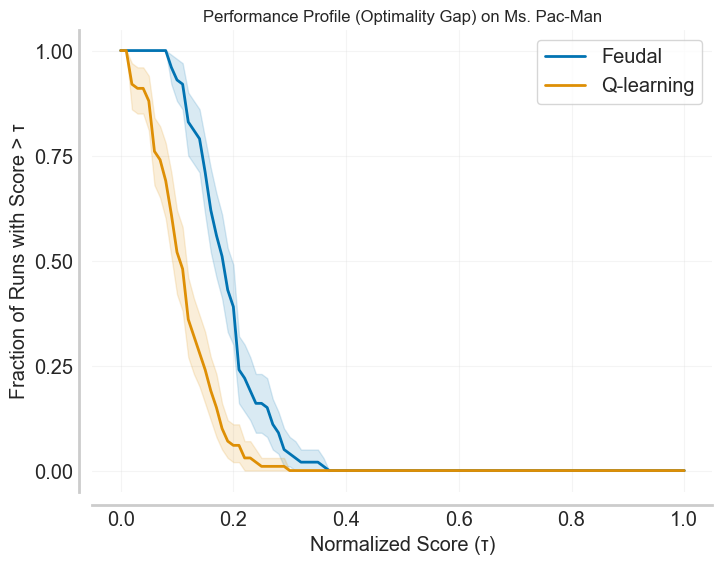

In [ ]:
# rliable

rliable_scores = {name: scores[:, np.newaxis] for name, scores in normalized_scores.items()}

thresholds = np.linspace(0, 1.0, 101)
profiles, profile_cis = rly.create_performance_profile(rliable_scores, thresholds, reps=2000)

fig, ax = plt.subplots(figsize=(8, 6))
plot_utils.plot_performance_profiles(profiles, thresholds, performance_profile_cis=profile_cis, ax=ax, legend=True)
ax.set_title('Performance Profile (Optimality Gap) on Ms. Pac-Man')
ax.set_xlabel('Normalized Score (τ)')
ax.set_ylabel('Fraction of Runs with Score > τ')
plt.grid(True)
plt.show()

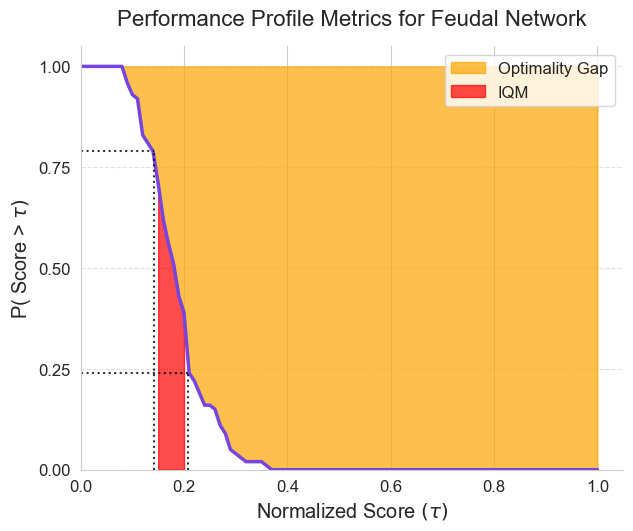

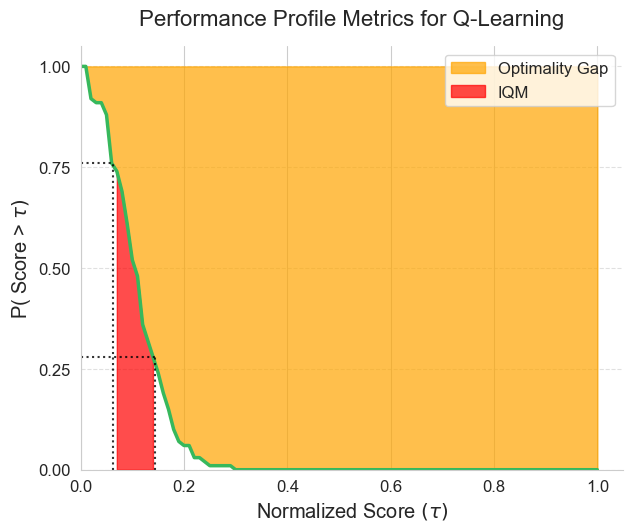

In [ ]:
# Annotated Perf profiles

plot_annotated_profile(
    scores=normalized_scores['Feudal'],
    profile=profiles['Feudal'],
    thresholds=thresholds,
    algo_name='Feudal Network',
    color=COLORS['Feudal_Profile']
)

plot_annotated_profile(
    scores=normalized_scores['Q-learning'],
    profile=profiles['Q-learning'],
    thresholds=thresholds,
    algo_name='Q-Learning',
    color=COLORS['Q_Profile']
)